# XGBoost v7 (New Dataset)

What changed from v6:
1. Swapped in a new dataset with 49 features instead of 18
2. Added lag features: cancelled_yesterday, lag1_cancel_rate, lag1_delay_rate
3. Added monthly and seasonal historical averages per airport
4. Everything else is the same as v6: same SMOTE, same scale_pos_weight=10, same class weights

The idea is that knowing what happened at an airport yesterday, and how that airport typically performs in January or in summer, is probably a stronger signal than just knowing the weather. v6 got 0.4152 on test, let's see if the new features push it higher.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Load Data

In [2]:
df = pd.read_parquet('../../../1_download_data/cleansed/modeling_dataset.parquet')
print('shape:', df.shape)

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

# 45 features -- the new ones are the lag/ops/rate columns at the bottom
features = [
    'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity',
    'Airline_enc', 'Origin_enc', 'region_enc', 'weather_source_enc',
    'airline_delay_rate', 'airline_cancel_rate',
    'airport_delay_rate', 'airport_cancel_rate',
    'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume',
    'cancelled_yesterday', 'hourly_flights', 'airport_operations',
    'ops_per_runway', 'num_runways', 'max_runway_length_ft', 'airport_elevation',
    'lag1m_carrier_delay', 'lag1m_weather_delay', 'lag1m_nas_delay',
    'lag1m_late_aircraft_delay', 'lag1m_security_delay','month_avg_cancel_rate', 'month_avg_delay_rate','season_avg_cancel_rate', 'season_avg_delay_rate'
]
features = [f for f in features if f in df.columns]
print(f'using {len(features)} features')

# model A: all flights, predicting cancelled vs not
X_train_a = train[features]; y_train_a = train['is_cancelled'].astype(int)
X_val_a   = val[features];   y_val_a   = val['is_cancelled'].astype(int)
X_test_a  = test[features];  y_test_a  = test['is_cancelled'].astype(int)

# model B: non-cancelled only, predicting delayed vs on_time
train_b = train[train['is_cancelled'] == 0]
val_b   = val[val['is_cancelled']     == 0]
test_b  = test[test['is_cancelled']   == 0]
X_train_b = train_b[features]; y_train_b = train_b['is_delayed'].astype(int)
X_val_b   = val_b[features];   y_val_b   = val_b['is_delayed'].astype(int)
X_test_b  = test_b[features];  y_test_b  = test_b['is_delayed'].astype(int)

y_val_true  = val['target'].astype(int).values
y_test_true = test['target'].astype(int).values

# cap to 2M
if len(X_train_a) > 2_000_000:
    idx = np.random.choice(len(X_train_a), 2_000_000, replace=False)
    X_train_a = X_train_a.iloc[idx]
    y_train_a = y_train_a.iloc[idx]

# fill NaNs before SMOTE
X_train_a = X_train_a.fillna(X_train_a.median())
X_val_a   = X_val_a.fillna(X_train_a.median())
X_test_a  = X_test_a.fillna(X_train_a.median())
X_train_b = X_train_b.fillna(X_train_b.median())
X_val_b   = X_val_b.fillna(X_train_b.median())
X_test_b  = X_test_b.fillna(X_train_b.median())

print(f'Model A -- train: {X_train_a.shape}, val: {X_val_a.shape}')
print(f'Model B -- train: {X_train_b.shape}, val: {X_val_b.shape}')

shape: (24165691, 56)
using 49 features
Model A -- train: (2000000, 49), val: (6310951, 49)
Model B -- train: (13535123, 49), val: (6199937, 49)


## SMOTE Resampling

Same approach as v6: oversample the cancelled class to give model A a better chance of learning the cancellation signal.

In [3]:
# same SMOTE settings as v6
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_a_res, y_train_a_res = smote.fit_resample(X_train_a, y_train_a)

print(f'before SMOTE:  cancelled: {y_train_a.sum():,}, not cancelled: {(y_train_a==0).sum():,}')
print(f'after SMOTE:  cancelled: {y_train_a_res.sum():,}, not cancelled: {(y_train_a_res==0).sum():,}')

weights_b = compute_sample_weight('balanced', y_train_b)
print('resampling done')

before SMOTE:  cancelled: 35,030, not cancelled: 1,964,970
after SMOTE:  cancelled: 392,994, not cancelled: 1,964,970
resampling done


## Model A (Cancellation)

Binary classifier: cancelled vs not cancelled.

In [4]:
model_a = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=10,  # same as v6
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_a.fit(X_train_a_res, y_train_a_res,
            eval_set=[(X_val_a, y_val_a)],
            verbose=False)
print('model A done')

model A done


Model A val PR-AUC: 0.0959
               precision    recall  f1-score   support

not_cancelled       0.99      0.96      0.97   6199937
    cancelled       0.10      0.21      0.13    111014

     accuracy                           0.95   6310951
    macro avg       0.54      0.59      0.55   6310951
 weighted avg       0.97      0.95      0.96   6310951



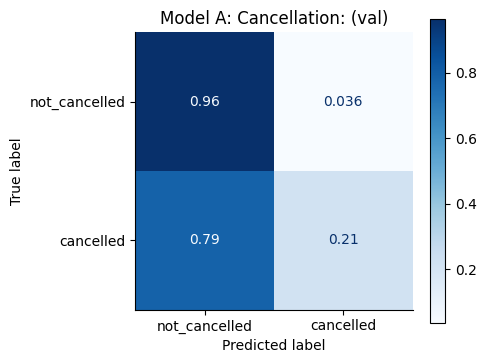

In [5]:
pred_a_val = model_a.predict(X_val_a)
prauc_a = average_precision_score(y_val_a, model_a.predict_proba(X_val_a)[:, 1])
print(f'Model A val PR-AUC: {prauc_a:.4f}')
print(classification_report(y_val_a, pred_a_val,
      target_names=['not_cancelled', 'cancelled'], zero_division=0))

cm_a = confusion_matrix(y_val_a, pred_a_val)
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
fig_a, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_a_norm, display_labels=['not_cancelled', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model A: Cancellation: (val)')
plt.tight_layout()
plt.show()

## Model B (Delay)

Binary classifier: delayed vs on_time, trained only on flights model A didn't flag as cancelled.

In [6]:
model_b = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_b.fit(X_train_b, y_train_b,
            sample_weight=weights_b,
            eval_set=[(X_val_b, y_val_b)],
            verbose=False)
print('model B done')

model B done


              precision    recall  f1-score   support

     on_time       0.89      0.71      0.79   5127027
     delayed       0.30      0.59      0.40   1072910

    accuracy                           0.69   6199937
   macro avg       0.60      0.65      0.59   6199937
weighted avg       0.79      0.69      0.72   6199937



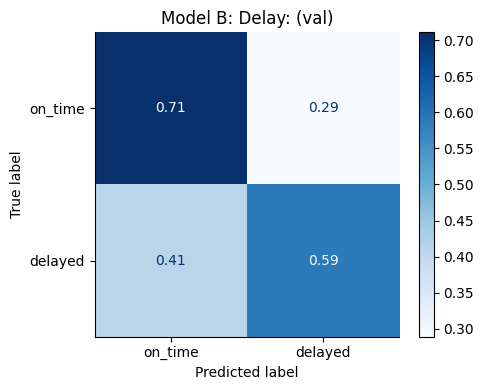

In [7]:
pred_b_val = model_b.predict(X_val_b)
print(classification_report(y_val_b, pred_b_val,
      target_names=['on_time', 'delayed'], zero_division=0))

cm_b = confusion_matrix(y_val_b, pred_b_val)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)
fig_b, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_b_norm, display_labels=['on_time', 'delayed']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model B: Delay: (val)')
plt.tight_layout()
plt.show()

## Putting It Togethe: **Cascade Evaluation**

Combining both models into the full three-class prediction.

val cascade macro F1: 0.4302
              precision    recall  f1-score   support

     on_time       0.88      0.70      0.78   5127027
     delayed       0.29      0.53      0.37   1072910
   cancelled       0.10      0.21      0.13    111014

    accuracy                           0.67   6310951
   macro avg       0.42      0.48      0.43   6310951
weighted avg       0.77      0.67      0.70   6310951



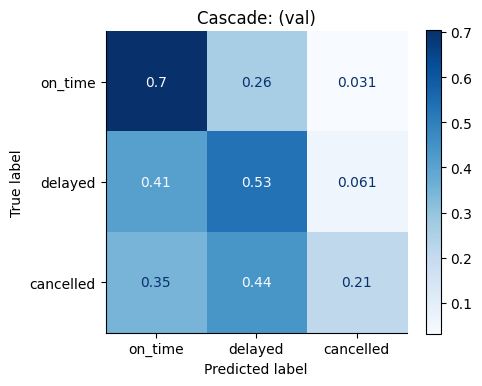

In [8]:
def cascade_predict(X, model_a, model_b, thresh_a=0.5, thresh_b=0.5):
    cancelled = model_a.predict_proba(X)[:, 1] >= thresh_a
    delayed   = model_b.predict_proba(X)[:, 1] >= thresh_b
    return np.where(cancelled, 2, np.where(delayed, 1, 0))

y_val_pred = cascade_predict(X_val_a, model_a, model_b)
mf1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'val cascade macro F1: {mf1_val:.4f}')
print(classification_report(y_val_true, y_val_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_val_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
fig_val, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_val_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade: (val)')
plt.tight_layout()
plt.show()

## Test Set Results

test cascade macro F1: 0.4199
              precision    recall  f1-score   support

     on_time       0.85      0.61      0.71   3091391
     delayed       0.32      0.54      0.40    863057
   cancelled       0.10      0.30      0.15    123191

    accuracy                           0.59   4077639
   macro avg       0.42      0.48      0.42   4077639
weighted avg       0.71      0.59      0.63   4077639



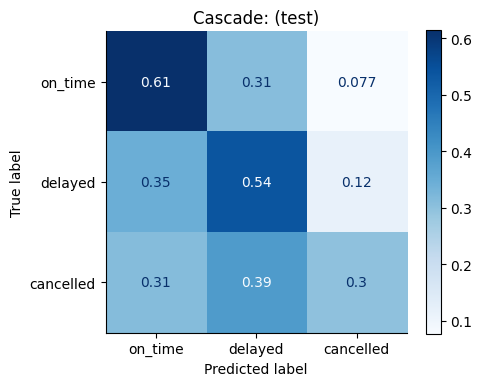

In [9]:
y_test_pred = cascade_predict(X_test_a, model_a, model_b)
mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'test cascade macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
fig_test, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_test_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade: (test)')
plt.tight_layout()
plt.show()

## v1 through v7 Comparison

Does the new dataset give us another bump on top of v6?

          model  val macro F1  test macro F1
v1 flights only        0.3054         0.2954
    v2 +weather        0.3641         0.3594
    v3 +weights        0.3750         0.3770
        v4 +spw        0.2795         0.2614
v5 cascade +spw        0.3624         0.3582
      v6 +SMOTE        0.4035         0.4152
    v7 new data        0.4302         0.4199


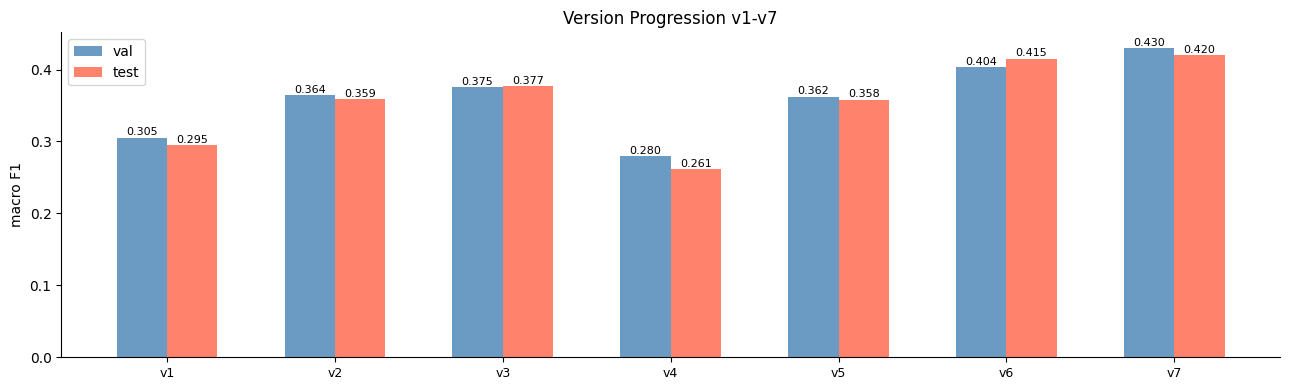

In [10]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770
v4_val,  v4_test  = 0.2795, 0.2614
v5_val,  v5_test  = 0.3624, 0.3582
v6_val,  v6_test  = 0.4035, 0.4152

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights',
                      'v4 +spw', 'v5 cascade +spw', 'v6 +SMOTE', 'v7 new data'],
    'val macro F1':  [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(13, 4))
x = np.arange(7)
width = 0.3
vals  = [v1_val, v2_val, v3_val, v4_val, v5_val, v6_val, mf1_val]
tests = [v1_test, v2_test, v3_test, v4_test, v5_test, v6_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('Version Progression v1-v7')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance

Which features mattered most for each model?

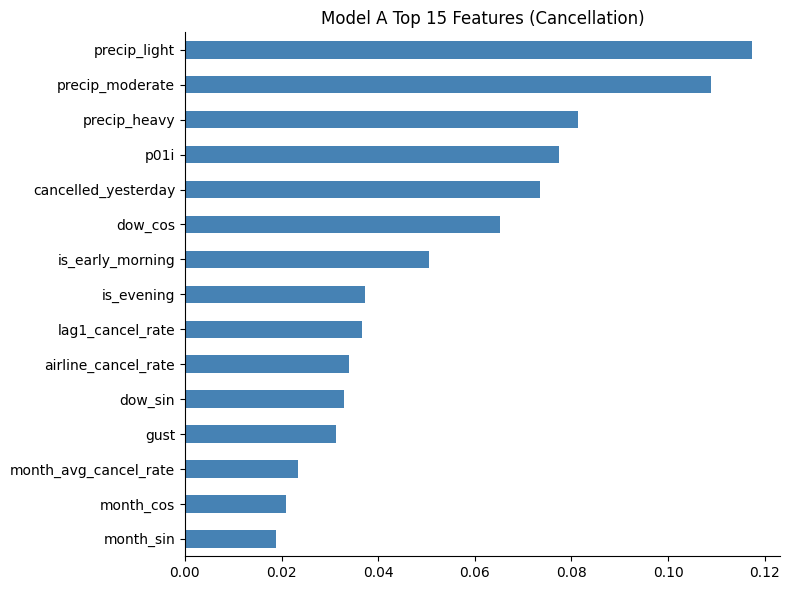

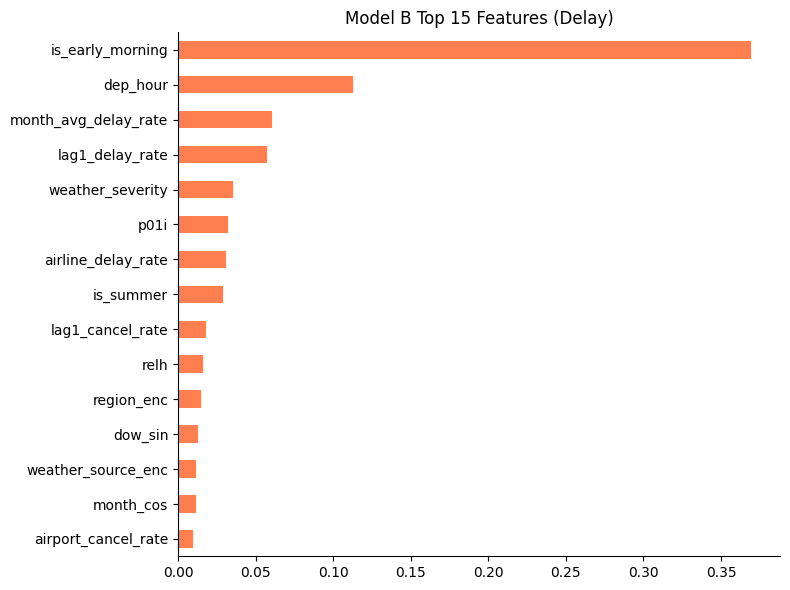

In [12]:
os.makedirs('./results_visuals', exist_ok=True)
# model A feature importance
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_a = pd.Series(model_a.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_imp_a.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Model A Top 15 Features (Cancellation)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# model B feature importance
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_b = pd.Series(model_b.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_imp_b.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Model B Top 15 Features (Delay)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

New dataset pushed test F1 from 0.4152 to 0.4199, not a huge jump but the right direction. Looking at feature importance, precipitation features dominate model A's cancellation predictions, with cancelled_yesterday and lag1_cancel_rate also playing a meaningful role. For model B, departure time features like is_early_morning and dep_hour matter most, with month_avg_delay_rate and lag1_delay_rate close behind.

Next up is v8 where we try to squeeze more out through hyperparameter tuning.